# Import

In [ ]:
# Repo-relative paths: inputs are read from imports_stable/, outputs are written to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"
for _d in ["", "plots/qc"]:
    os.makedirs(f"{OUTS_DIR}/{_d}", exist_ok=True)

In [2]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import muon as mu
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


# Counting Perturbations

In [3]:
rna = sc.read_h5ad(IMPORTS_DIR + "/SIG13/scanpy_outs/SIG13_doublets_DSB7.h5ad")

/tmp/ipykernel_878853/3907230808.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  callCounts = rna.obs.groupby('feature_call_DSB7').size().reset_index(name='counts').sort_values(by='counts', ascending=False)


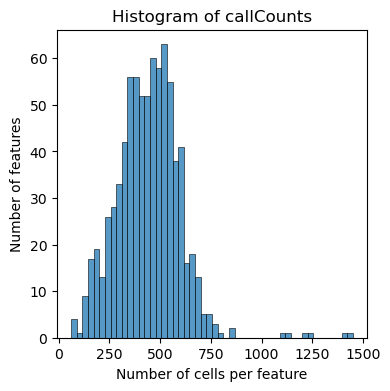

In [4]:
callCounts = rna.obs.groupby('feature_call_DSB7').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

plt.figure(figsize=(4, 4))
g = sns.histplot(callCounts['counts'], bins=50, kde=False)
g.set_xlabel('Number of cells per feature')
g.set_ylabel('Number of features')
g.set_title('Histogram of callCounts')
plt.savefig(OUTS_DIR + "/plots/qc/barcode_calling_DSB7_callCounts_histogram.pdf", bbox_inches='tight')

In [5]:
# get median cells per condition
callCounts.counts.median()

np.float64(447.0)

In [6]:
ligandCounts = rna.obs.groupby('ligand_call_DSB7').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

/tmp/ipykernel_878853/304750157.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ligandCounts = rna.obs.groupby('ligand_call_DSB7').size().reset_index(name='counts').sort_values(by='counts', ascending=False)


In [7]:
ligandCounts.to_csv(OUTS_DIR + "/SIG13_ligand_condition_counts.csv", index=False)

# RNA Quality

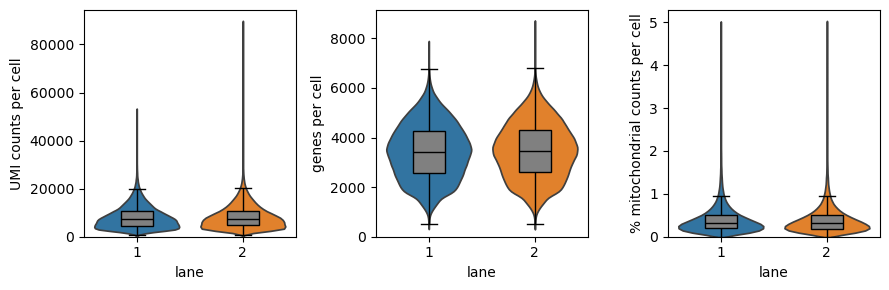

In [8]:
# plot bc UMI count density
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

sns.violinplot(data=rna.obs, x='lane', y='total_counts', hue='lane', ax=axes[0], inner=None)
sns.boxplot(data=rna.obs, x='lane', y='total_counts', ax=axes[0], width=0.3, color='grey', linecolor='black', showfliers=False)
axes[0].set_ylim(bottom=0)
axes[0].set_ylabel("UMI counts per cell")

sns.violinplot(data=rna.obs, x='lane', y='n_genes_by_counts', hue='lane', ax=axes[1], inner=None)
sns.boxplot(data=rna.obs, x='lane', y='n_genes_by_counts', ax=axes[1], width=0.3, color='grey', linecolor='black', showfliers=False)
axes[1].set_ylim(bottom=0)
axes[1].set_ylabel("genes per cell")

sns.violinplot(data=rna.obs, x='lane', y='pct_counts_mt', hue='lane', ax=axes[2], inner=None)
sns.boxplot(data=rna.obs, x='lane', y='pct_counts_mt', ax=axes[2], width=0.3, color='grey', linecolor='black', showfliers=False)
axes[2].set_ylim(bottom=0)
axes[2].set_ylabel("% mitochondrial counts per cell")

plt.tight_layout()
plt.savefig(OUTS_DIR + "/plots/qc/rna_quality_metrics.pdf", bbox_inches='tight')
plt.show()